/tmp/ipython-input-1569376107.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
/tmp/ipython-input-1569376107.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
/tmp/ipython-input-1569376107.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(


            SHRIRAMFIN.NS     SBIN.NS  ADANIPOWER.NS
Date                                                
2023-01-02     259.247101  578.999573      59.630001
2023-01-03     255.247147  579.188721      58.950001
2023-01-04     251.218903  572.379150      57.320000
2023-01-05     249.620819  572.284546      57.750000
2023-01-06     244.845505  568.075928      56.680000


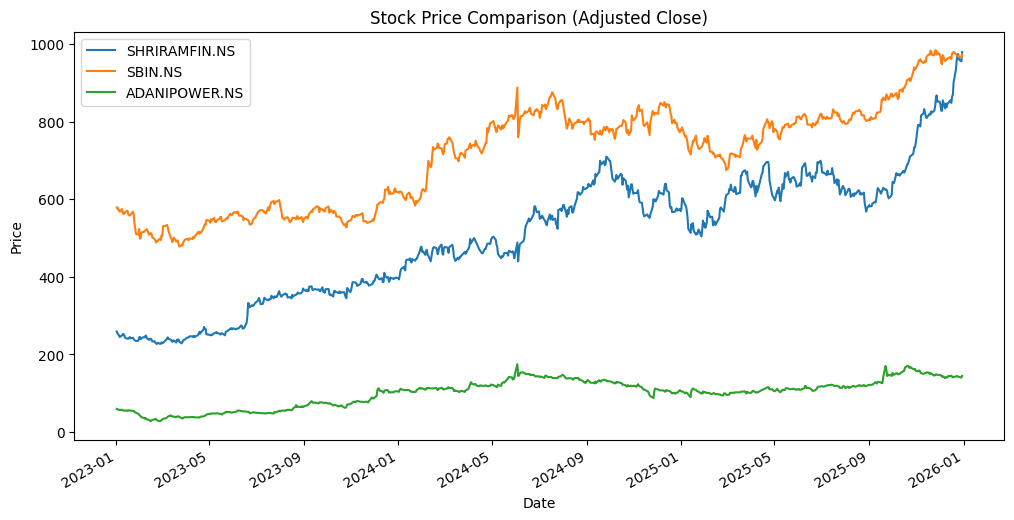

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

stocks = [
    {'ticker': 'SHRIRAMFIN.NS', 'name': 'Shriram Finance Limited'},
    {'ticker': 'SBIN.NS', 'name': 'State Bank of India'},
    {'ticker': 'ADANIPOWER.NS', 'name': 'Adani Power Limited'},
]

def create_plots(stocks):
    data = pd.DataFrame()

    for stock in stocks:
        df = yf.download(
            stock['ticker'],
            start='2023-01-01',
            progress=False
        )
        data[stock['ticker']] = df['Close']

    print(data.head())
    # Plot
    data.plot(figsize=(12,6))
    plt.title("Stock Price Comparison (Adjusted Close)")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.show()

create_plots(stocks)

In [94]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

df = yf.download("SBIN.NS", start="2025-01-01", progress=False)


/tmp/ipython-input-1115485746.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("SBIN.NS", start="2025-01-01", progress=False)


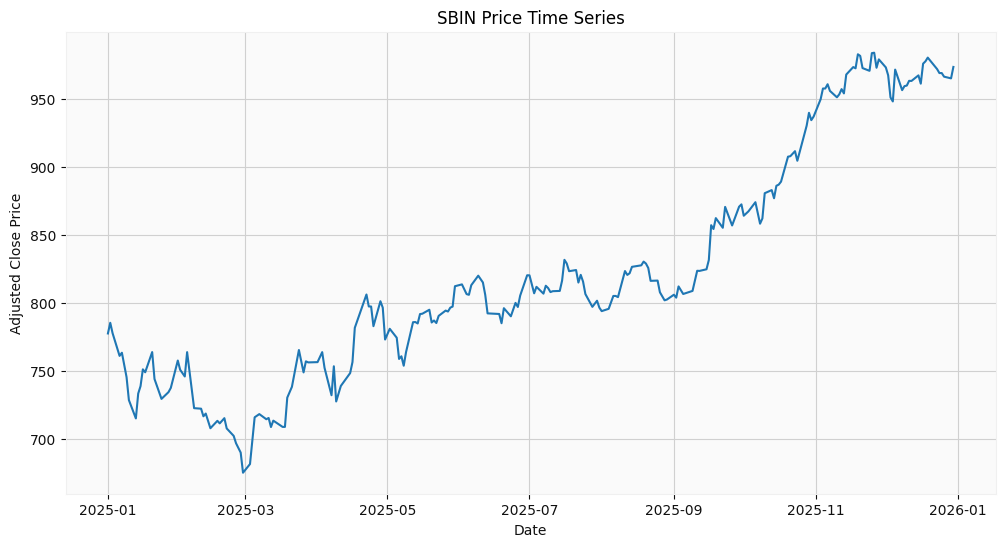

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'])
plt.title("SBIN Price Time Series")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.show()

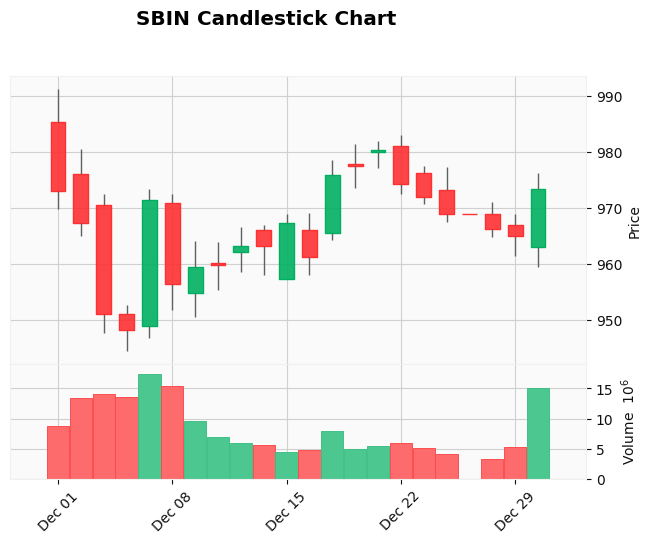

In [93]:
!pip install mplfinance
import mplfinance as mpf

# Preprocess DataFrame for mplfinance by dropping the second level of MultiIndex columns
df_mpf = df.copy()
df_mpf.columns = df_mpf.columns.droplevel(1)

mpf.plot(
    df_mpf, # Use the modified DataFrame
    type='candle',
    volume=True,
    style='yahoo',
    title='SBIN Candlestick Chart'
)

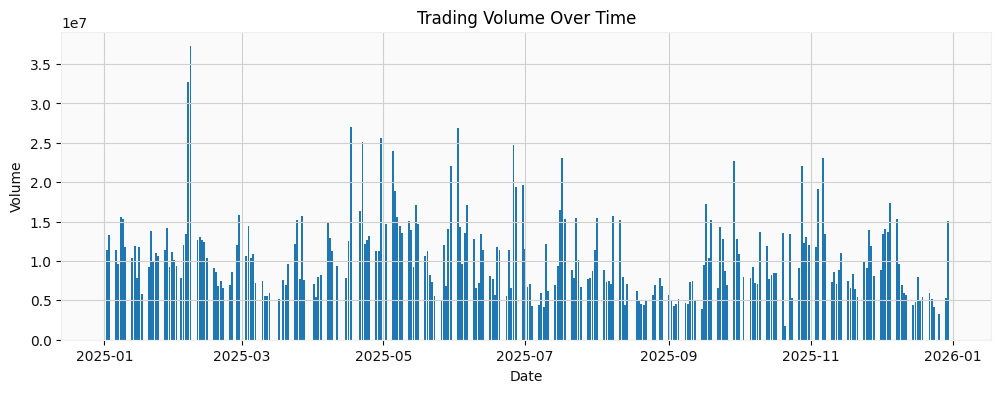

In [ ]:
plt.figure(figsize=(12,4))
plt.bar(df_mpf.index, df_mpf['Volume']) # Changed df['Volume'] to df_mpf['Volume']
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

In [ ]:
df['returns'] = df_mpf['Close'].pct_change()

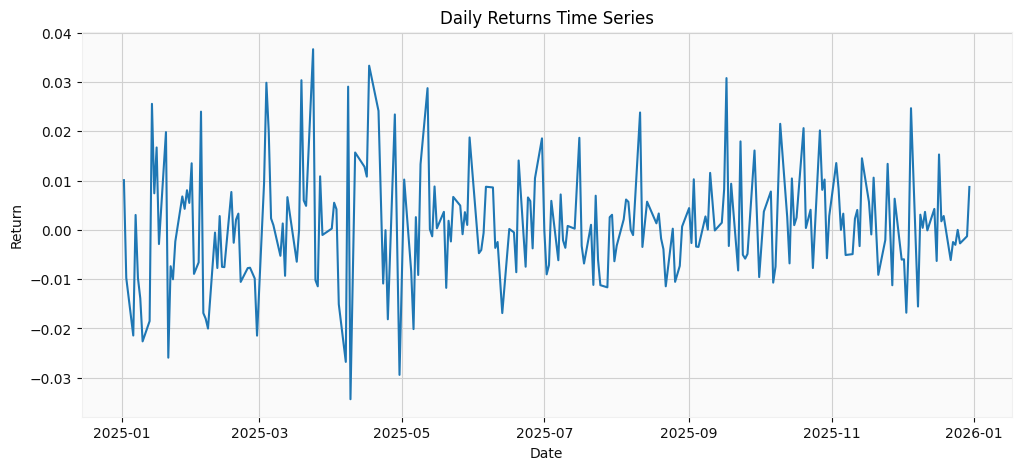

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['returns'])
plt.title("Daily Returns Time Series")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()


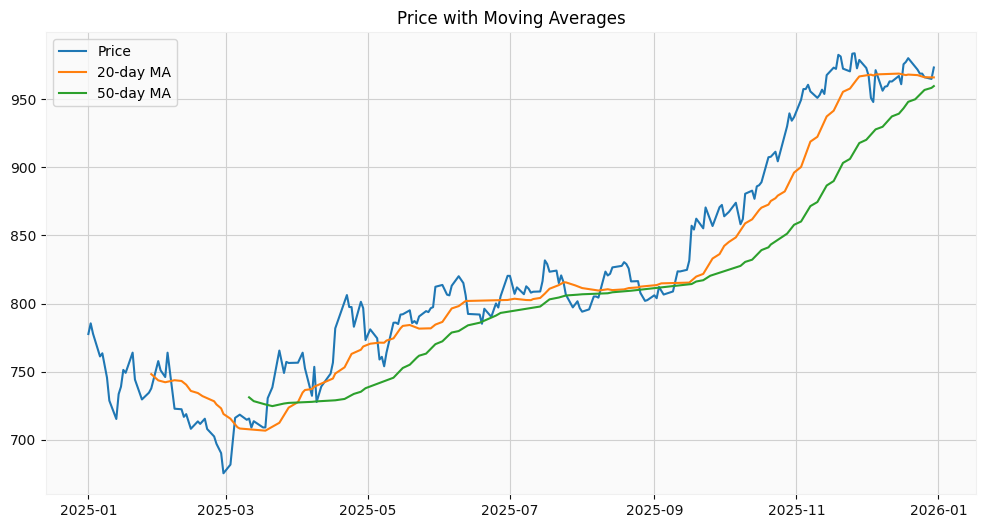

In [ ]:
df['MA_20'] = df['Close'].rolling(20).mean()
df['MA_50'] = df['Close'].rolling(50).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Price')
plt.plot(df['MA_20'], label='20-day MA')
plt.plot(df['MA_50'], label='50-day MA')
plt.legend()
plt.title("Price with Moving Averages")
plt.show()

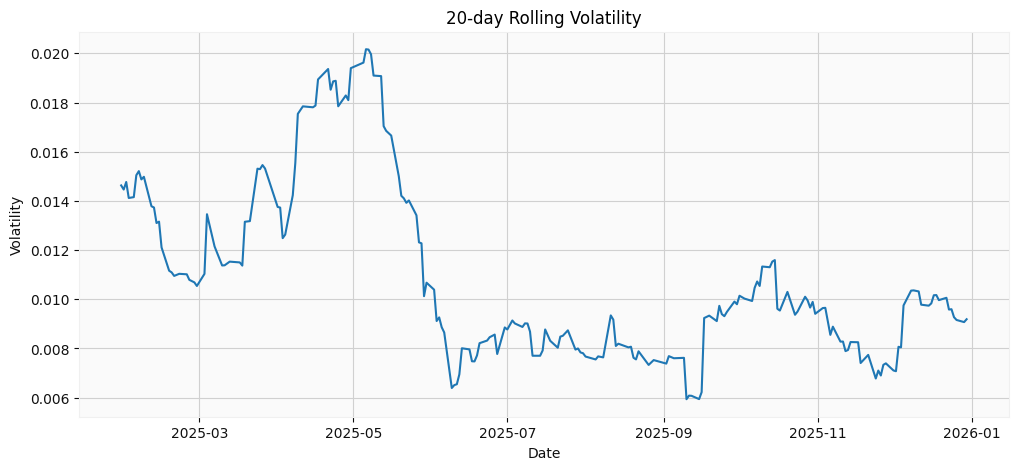

In [ ]:
df['volatility'] = df['returns'].rolling(20).std()

plt.figure(figsize=(12,5))
plt.plot(df['volatility'])
plt.title("20-day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()


In [ ]:
stocks = {
    'SHRIRAMFIN.NS': 'Shriram Finance',
    'SBIN.NS': 'State Bank of India',
    'ADANIPOWER.NS': 'Adani Power'
}


In [ ]:
start_date = "2025-01-01"

price_data = pd.DataFrame()

for ticker in stocks:
    df = yf.download(ticker, start=start_date, progress=False)
    price_data[ticker] = df['Close']


/tmp/ipython-input-1870936176.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, progress=False)
/tmp/ipython-input-1870936176.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, progress=False)
/tmp/ipython-input-1870936176.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, progress=False)


In [ ]:
price_data.dropna(inplace=True)


In [ ]:
normalized_prices = price_data / price_data.iloc[0] * 100


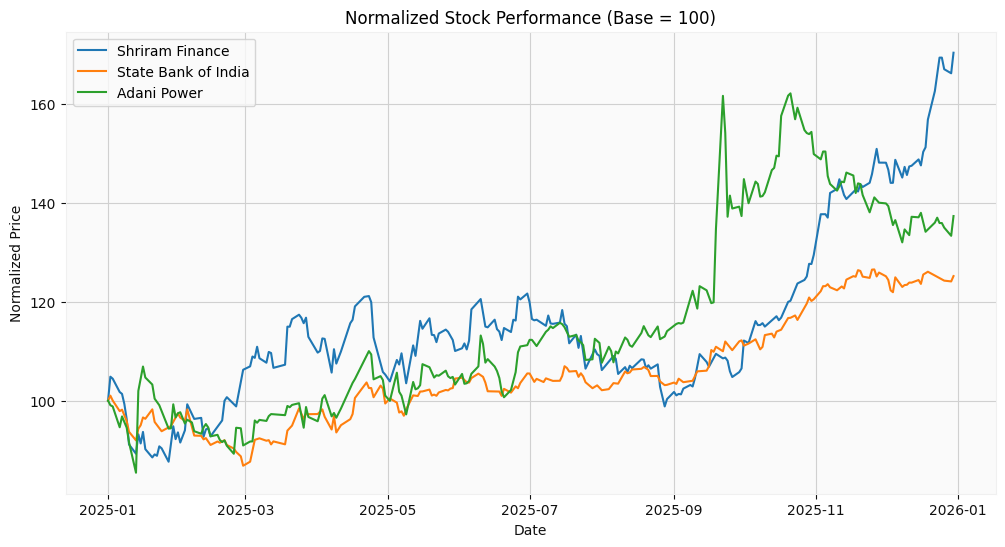

In [ ]:
plt.figure(figsize=(12,6))

for ticker, name in stocks.items():
    plt.plot(
        normalized_prices.index,
        normalized_prices[ticker],
        label=name
    )

plt.title("Normalized Stock Performance (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
returns = price_data.pct_change().dropna()


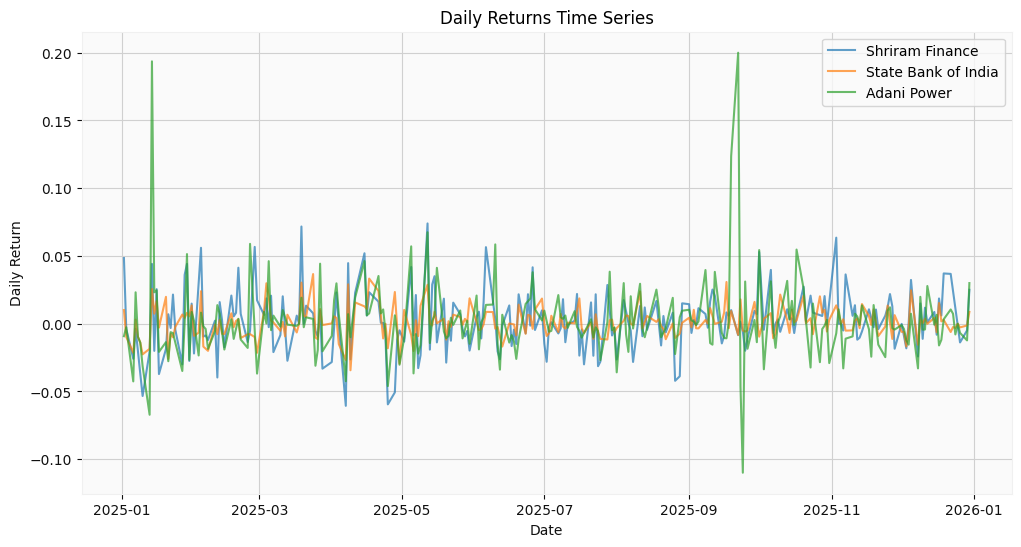

In [ ]:
plt.figure(figsize=(12,6))

for ticker, name in stocks.items():
    plt.plot(
        returns.index,
        returns[ticker],
        label=name,
        alpha=0.7
    )

plt.title("Daily Returns Time Series")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
rolling_vol = returns.rolling(window=20).std()


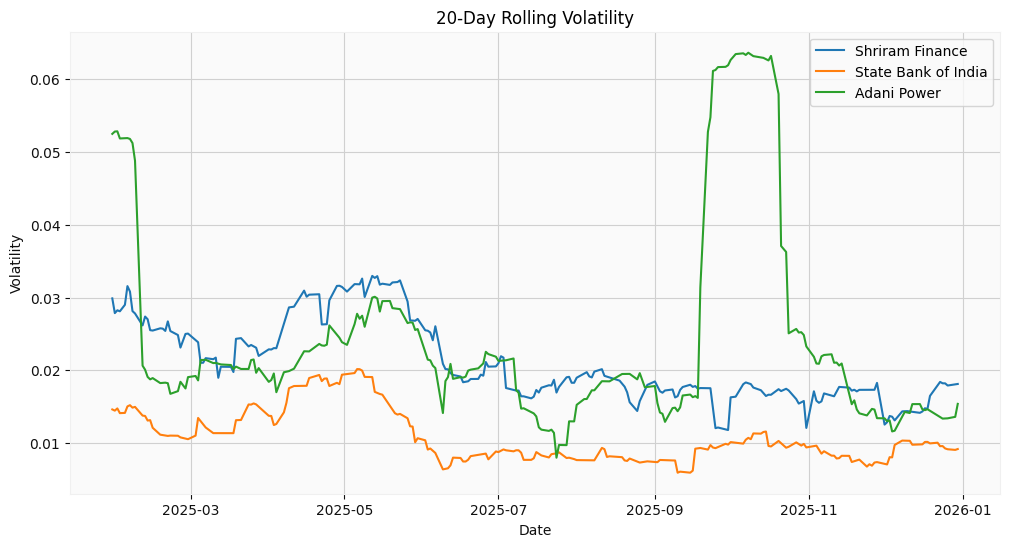

In [ ]:
plt.figure(figsize=(12,6))

for ticker, name in stocks.items():
    plt.plot(
        rolling_vol.index,
        rolling_vol[ticker],
        label=name
    )

plt.title("20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
annual_volatility = returns.std() * (252 ** 0.5)
print(annual_volatility)


SHRIRAMFIN.NS    0.346504
SBIN.NS          0.179261
ADANIPOWER.NS    0.456279
dtype: float64


In [ ]:
# Compute cumulative returns
cumulative_returns = (1 + returns).cumprod()

# Compute drawdowns
drawdowns = cumulative_returns / cumulative_returns.cummax() - 1


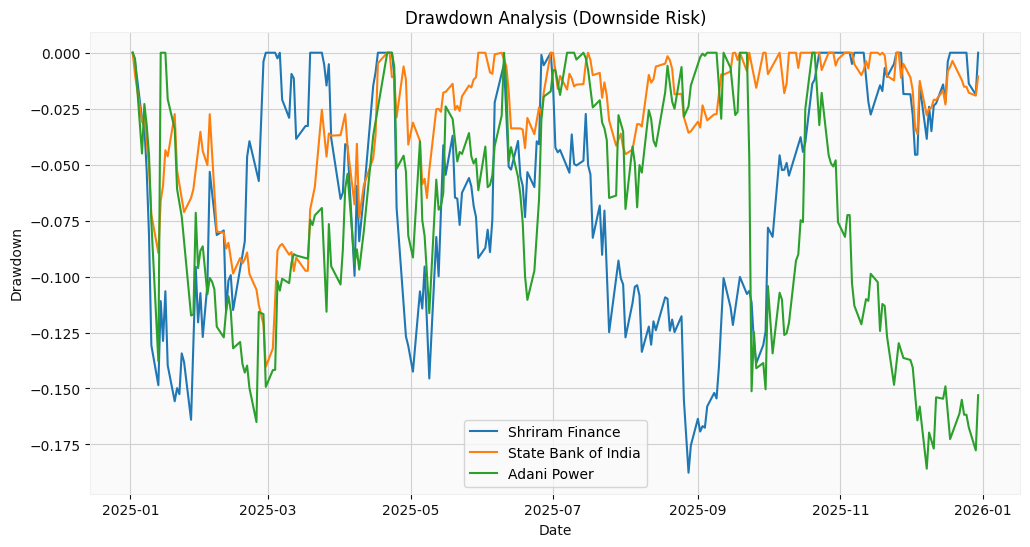

In [ ]:
plt.figure(figsize=(12,6))

for ticker, name in stocks.items():
    plt.plot(
        drawdowns.index,
        drawdowns[ticker],
        label=name
    )

plt.title("Drawdown Analysis (Downside Risk)")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
max_drawdown = drawdowns.min()
print("Maximum Drawdown:")
print(max_drawdown)


Maximum Drawdown:
SHRIRAMFIN.NS   -0.187643
SBIN.NS         -0.140290
ADANIPOWER.NS   -0.185853
dtype: float64


In [ ]:
correlation_matrix = returns.corr()
print(correlation_matrix)


               SHRIRAMFIN.NS   SBIN.NS  ADANIPOWER.NS
SHRIRAMFIN.NS       1.000000  0.423532       0.351939
SBIN.NS             0.423532  1.000000       0.289216
ADANIPOWER.NS       0.351939  0.289216       1.000000


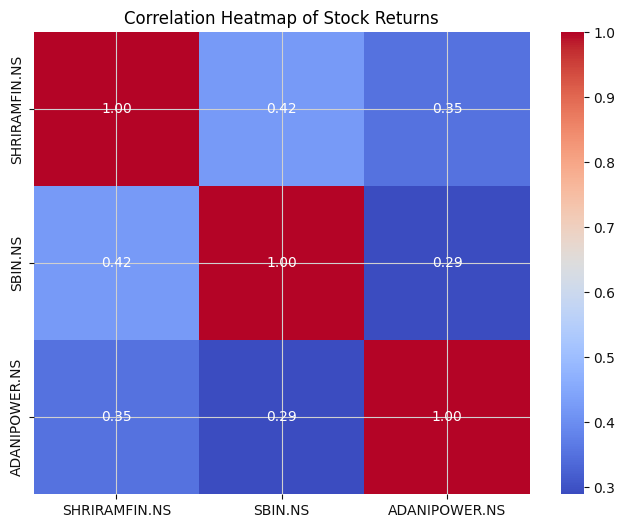

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap of Stock Returns")
plt.show()


In [ ]:
ticker = 'SBIN.NS'
price = price_data[ticker]


In [ ]:
ma_short = price.rolling(window=20).mean()
ma_long = price.rolling(window=50).mean()


In [ ]:
signals = pd.DataFrame(index=price.index)
signals['price'] = price
signals['ma_short'] = ma_short
signals['ma_long'] = ma_long

signals['signal'] = 0
signals.loc[signals['ma_short'] > signals['ma_long'], 'signal'] = 1
signals['position'] = signals['signal'].diff()


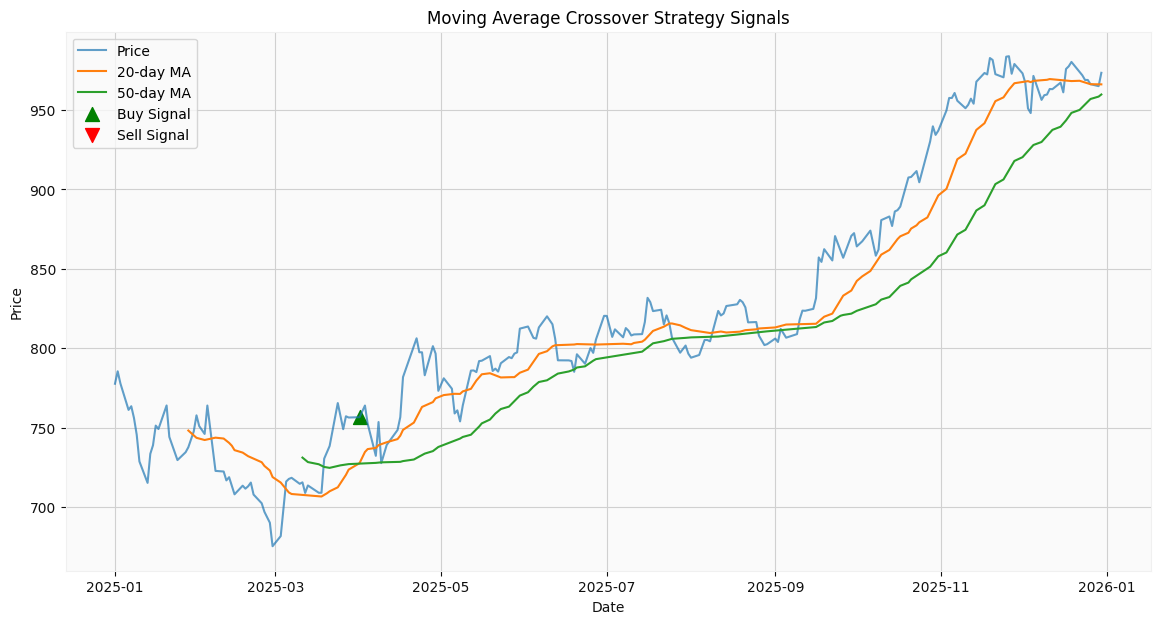

In [ ]:
plt.figure(figsize=(14,7))

plt.plot(signals.index, signals['price'], label='Price', alpha=0.7)
plt.plot(signals.index, signals['ma_short'], label='20-day MA')
plt.plot(signals.index, signals['ma_long'], label='50-day MA')

# Buy signals
plt.scatter(
    signals.index[signals['position'] == 1],
    signals['price'][signals['position'] == 1],
    marker='^',
    color='green',
    s=100,
    label='Buy Signal'
)

# Sell signals
plt.scatter(
    signals.index[signals['position'] == -1],
    signals['price'][signals['position'] == -1],
    marker='v',
    color='red',
    s=100,
    label='Sell Signal'
)

plt.title("Moving Average Crossover Strategy Signals")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


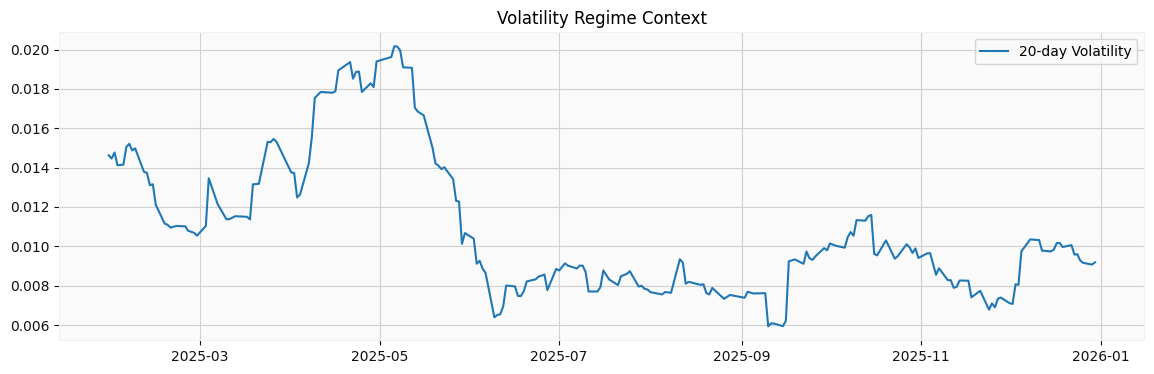

In [ ]:
volatility = returns[ticker].rolling(20).std()

plt.figure(figsize=(14,4))
plt.plot(volatility, label='20-day Volatility')
plt.title("Volatility Regime Context")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
strategy = signals.copy()

# Position: 1 when in trade, 0 otherwise
strategy['position'] = strategy['signal']

# Shift position to avoid lookahead bias
strategy['position'] = strategy['position'].shift(1)


In [ ]:
strategy['strategy_returns'] = strategy['position'] * returns[ticker]


In [ ]:
strategy['equity_curve'] = (1 + strategy['strategy_returns']).cumprod()


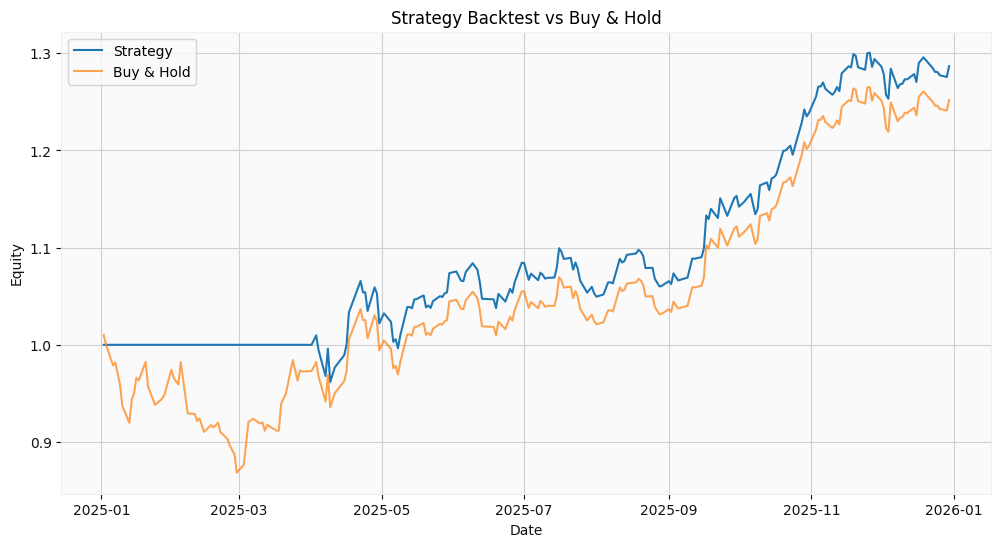

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(strategy.index, strategy['equity_curve'], label='Strategy')
plt.plot((1 + returns[ticker]).cumprod(), label='Buy & Hold', alpha=0.7)

plt.title("Strategy Backtest vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
annual_return = strategy['strategy_returns'].mean() * 252


In [ ]:
annual_vol = strategy['strategy_returns'].std() * (252 ** 0.5)


In [ ]:
sharpe_ratio = annual_return / annual_vol


In [ ]:
rolling_max = strategy['equity_curve'].cummax()
drawdown = strategy['equity_curve'] / rolling_max - 1
max_drawdown = drawdown.min()


In [ ]:
print(f"Annual Return: {annual_return:.2%}")
print(f"Annual Volatility: {annual_vol:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2%}")


Annual Return: 26.55%
Annual Volatility: 14.32%
Sharpe Ratio: 1.85
Max Drawdown: -6.49%


In [ ]:
momentum = returns[ticker].rolling(20).mean()


In [ ]:
vol_filter = returns[ticker].rolling(20).std()
vol_threshold = vol_filter.median()


In [ ]:
strategy['alpha_signal'] = 0

strategy.loc[
    (strategy['ma_short'] > strategy['ma_long']) &
    (momentum > 0) &
    (vol_filter < vol_threshold),
    'alpha_signal'
] = 1


In [ ]:
strategy['alpha_position'] = strategy['alpha_signal'].shift(1)
strategy['alpha_returns'] = strategy['alpha_position'] * returns[ticker]
strategy['alpha_equity'] = (1 + strategy['alpha_returns']).cumprod()


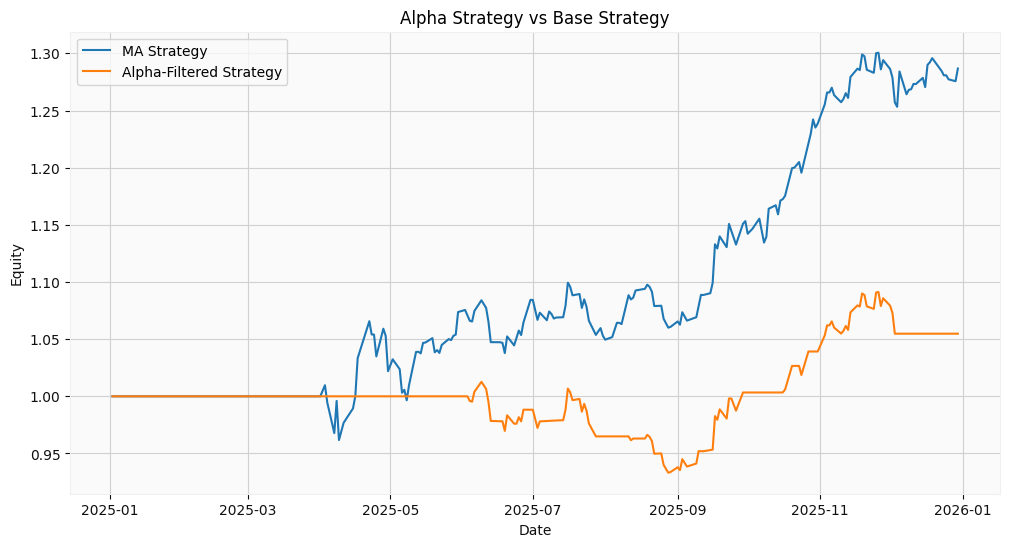

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(strategy['equity_curve'], label='MA Strategy')
plt.plot(strategy['alpha_equity'], label='Alpha-Filtered Strategy')

plt.title("Alpha Strategy vs Base Strategy")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
strategy['position'] = strategy['signal'].shift(1)


In [ ]:
strategy['trade'] = strategy['position'].diff().abs()


In [101]:
cost_rate = 0.01  # 0.1% per trade


In [ ]:
strategy['transaction_cost'] = strategy['trade'] * cost_rate


In [ ]:
strategy['strategy_returns'] = strategy['position'] * returns[ticker]


In [ ]:
strategy['net_returns'] = (
    strategy['position'] * returns[ticker]
    - strategy['transaction_cost']
)


In [ ]:
strategy['net_equity'] = (1 + strategy['net_returns']).cumprod()


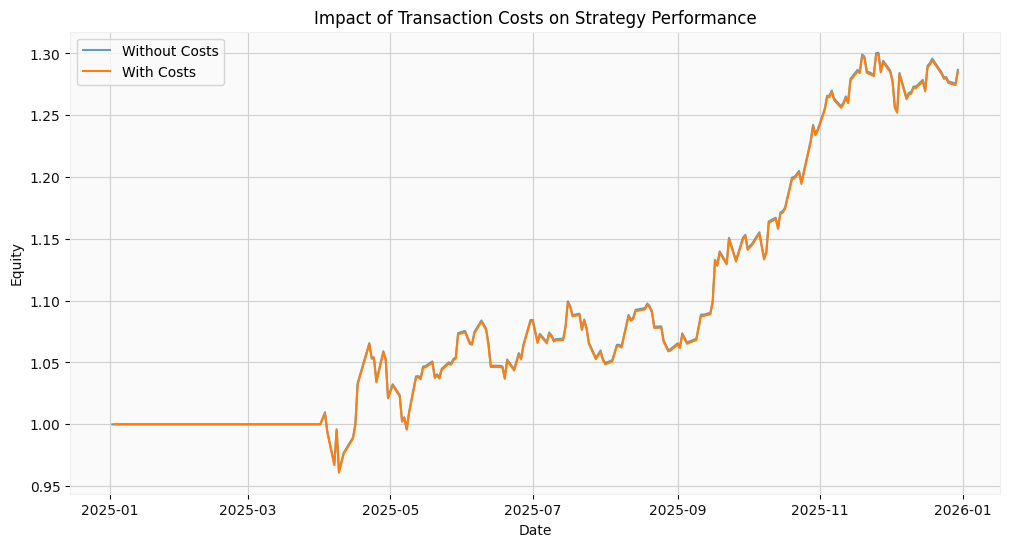

In [100]:
plt.figure(figsize=(12,6))

plt.plot(strategy['equity_curve'], label='Without Costs', alpha=0.7)
plt.plot(strategy['net_equity'], label='With Costs')

plt.title("Impact of Transaction Costs on Strategy Performance")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
net_annual_return = strategy['net_returns'].mean() * 252
net_annual_vol = strategy['net_returns'].std() * (252 ** 0.5)
net_sharpe = net_annual_return / net_annual_vol

rolling_max = strategy['net_equity'].cummax()
net_drawdown = strategy['net_equity'] / rolling_max - 1
net_max_drawdown = net_drawdown.min()


In [ ]:
print("=== Strategy Performance (After Costs) ===")
print(f"Annual Return: {net_annual_return:.2%}")
print(f"Annual Volatility: {net_annual_vol:.2%}")
print(f"Sharpe Ratio: {net_sharpe:.2f}")
print(f"Max Drawdown: {net_max_drawdown:.2%}")


=== Strategy Performance (After Costs) ===
Annual Return: 26.55%
Annual Volatility: 14.35%
Sharpe Ratio: 1.85
Max Drawdown: -6.49%
